# Simulation INS + VOR/DME avec IMM

Notebook de simulation pour l'hybridation centrale inertielle (INS) et moyens de radionavigation terrestres (VOR/DME) utilisant un **Interacting Multiple Model (IMM)**.

## Objectifs
- Simuler la dynamique d'un aeronef equipe d'une INS et de recepteurs VOR/DME
- Comparer les performances INS seule vs INS corrigee par VOR/DME via **IMM**
- Evaluer l'apport de la gestion multi-modeles par rapport a l'EKF classique
- Analyser les transitions entre modes de vol

## Principe IMM
- 3 modeles en parallele: rectiligne, virage, acceleration
- Probabilites de mode adaptatives
- Fusion ponderee des estimations
- Matrice de transition entre modes

## Auteur
Nicolas CUSSEAU - ENSTA ILEMS - Projet SAFRAN

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from parametres import *
from modeles_dynamique import *
from stations_sol import *
from generateur_trajectoire import *
from simulateur_ins import *

# Recharger le module IMM
import importlib
import imm
importlib.reload(imm)
from imm import IMM

from metriques import *
from visualisation import *

# Configuration matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

print("[OK] Imports realises (IMM)")

[OK] Imports realises (IMM)


## 2. Chargement parametres

In [2]:
# Chargement parametres par defaut
params_sim, params_ins, params_vor_dme, params_ekf = charger_parametres_defaut()

# Creation stations VOR/DME
stations = creer_stations_sol()

print("[OK] Parametres charges")
print(f"Duree simulation: {params_sim.duree_simulation} s")
print(f"Frequence IMU: {1.0/params_sim.dt_imu} Hz")
print(f"Nombre de stations: {len(stations)}")
for station in stations:
    print(f"  - {station.nom}: position {station.position} m")

[OK] Parametres charges
Duree simulation: 1200.0 s
Frequence IMU: 100.0 Hz
Nombre de stations: 3
  - Station 1: position [0. 0. 0.] m
  - Station 2: position [80000.     0.     0.] m
  - Station 3: position [40000. 60000.     0.] m


## 3. Choix scenario

Scenarios disponibles:
- **1**: Approche radiale vers station 1
- **2**: Arc circulaire autour station 1
- **3**: Transit multi-stations
- **4**: Trajectoire reelle GPS (data.csv)
- **5**: Transit balises reelles (DJL, RLP, LXI, EPL, LUL)

In [ ]:
# Selection scenario
numero_scenario = 3

if numero_scenario == 1:
    verite = generer_verite_scenario_1(params_sim)
    nom_scenario = "Approche radiale"
elif numero_scenario == 2:
    verite = generer_verite_scenario_2(params_sim)
    nom_scenario = "Arc circulaire"
elif numero_scenario == 3:
    verite = generer_verite_scenario_3(params_sim)
    nom_scenario = "Transit multi-stations"
elif numero_scenario == 4:
    verite = generer_verite_scenario_4(params_sim)
    nom_scenario = "Trajectoire reelle GPS"
else:
    verite = generer_verite_scenario_5(params_sim)
    nom_scenario = "Transit balises reelles"

print(f"[OK] Scenario {numero_scenario} genere: {nom_scenario}")
print(f"Nombre d'echantillons: {len(verite['t'])}")
print(f"Position initiale: N={verite['N'][0]:.0f} m, E={verite['E'][0]:.0f} m")
print(f"Position finale: N={verite['N'][-1]:.0f} m, E={verite['E'][-1]:.0f} m")

[OK] Scenario 3 genere: Transit multi-stations
Nombre d'echantillons: 120001
Position initiale: N=-20000 m, E=-20000 m
Position finale: N=67310 m, E=24185 m


## 4. Generation mesures IMU

In [4]:
# Generation mesures IMU bruitees
mesures_imu = generer_mesures_imu_bruitees(verite, params_ins)

print("[OK] Mesures IMU generees")
print(f"Biais gyro initial: {mesures_imu['b_g_reel'][0]:.6f} rad/s = {np.rad2deg(mesures_imu['b_g_reel'][0]):.3f} deg/s")
print(f"Biais gyro final: {mesures_imu['b_g_reel'][-1]:.6f} rad/s = {np.rad2deg(mesures_imu['b_g_reel'][-1]):.3f} deg/s")
print(f"Biais accel initial: {mesures_imu['b_a_reel'][0]:.6f} m/s^2")
print(f"Biais accel final: {mesures_imu['b_a_reel'][-1]:.6f} m/s^2")

[OK] Mesures IMU generees
Biais gyro initial: 0.005240 rad/s = 0.300 deg/s
Biais gyro final: 0.006048 rad/s = 0.347 deg/s
Biais accel initial: 0.029400 m/s^2
Biais accel final: 0.009734 m/s^2


## 5. Simulation INS seule

In [5]:
# Etat initial avec erreurs realistes
np.random.seed(42)  # Reproductibilite

# Generation erreurs aleatoires
err_N = np.random.randn() * 50.0  # 50m std
err_E = np.random.randn() * 50.0
err_V_N = np.random.randn() * 2.0  # 2 m/s std
err_V_E = np.random.randn() * 2.0
err_psi = np.random.randn() * 0.0349  # 2 deg std
err_b_g = params_ins.gyro_biais_init * 0.5  # 50% erreur estimation
err_b_a = params_ins.accel_biais_init * 0.5

x0 = np.array([
    verite['N'][0] + err_N,
    verite['E'][0] + err_E,
    verite['h'][0],
    verite['V_N'][0] + err_V_N,
    verite['V_E'][0] + err_V_E,
    verite['psi'][0] + err_psi,
    params_ins.gyro_biais_init + err_b_g,
    params_ins.accel_biais_init + err_b_a
])

print("Erreurs initiales:")
print(f"  Position: dN={err_N:.1f}m, dE={err_E:.1f}m")
print(f"  Vitesse: dV_N={err_V_N:.2f}m/s, dV_E={err_V_E:.2f}m/s")
print(f"  Cap: dpsi={np.rad2deg(err_psi):.2f}deg")
print(f"  Biais gyro: {np.rad2deg(err_b_g):.4f}deg/s")
print(f"  Biais accel: {err_b_a:.4f}m/s^2")
print()

# Integration INS seule (dead reckoning)
traj_ins_seule = integrer_ins_seule(mesures_imu, x0, params_sim, params_ins)

print("[OK] Integration INS seule terminee")
print(f"Position finale INS: N={traj_ins_seule['N'][-1]:.0f} m, E={traj_ins_seule['E'][-1]:.0f} m")
print(f"Erreur finale 2D: {np.sqrt((traj_ins_seule['N'][-1] - verite['N'][-1])**2 + (traj_ins_seule['E'][-1] - verite['E'][-1])**2):.0f} m")

Erreurs initiales:
  Position: dN=24.8m, dE=-6.9m
  Vitesse: dV_N=1.30m/s, dV_E=3.05m/s
  Cap: dpsi=-0.47deg
  Biais gyro: 0.1501deg/s
  Biais accel: 0.0147m/s^2

[OK] Integration INS seule terminee
Position finale INS: N=77949 m, E=40609 m
Erreur finale 2D: 19568 m


## 6. Simulation INS + IMM

In [6]:
# Initialisation IMM
imm_filter = IMM(x0, params_ekf.P0, params_ins, params_vor_dme, params_ekf)

# Reinitialisation timers stations
for station in stations:
    station.prochain_temps_mesure = 1.0 / station.frequence_mesure

# Initialisation stockage trajectoire IMM
N_samples = len(verite['t'])
traj_imm = {
    't': verite['t'].copy(),
    'N': np.zeros(N_samples),
    'E': np.zeros(N_samples),
    'h': np.zeros(N_samples),
    'V_N': np.zeros(N_samples),
    'V_E': np.zeros(N_samples),
    'psi': np.zeros(N_samples),
    'b_g': np.zeros(N_samples),
    'b_a': np.zeros(N_samples),
    'mode': np.zeros(N_samples, dtype=int),
    'mu': np.zeros((N_samples, 3))
}

# Etat initial
for i, key in enumerate(['N', 'E', 'h', 'V_N', 'V_E', 'psi', 'b_g', 'b_a']):
    traj_imm[key][0] = imm_filter.x[i]
traj_imm['mode'][0] = np.argmax(imm_filter.mu)
traj_imm['mu'][0] = imm_filter.mu.copy()

# Compteurs mesures
n_mesures_vor_acceptees = 0
n_mesures_vor_rejetees = 0
n_mesures_dme_acceptees = 0
n_mesures_dme_rejetees = 0

print("[INFO] Debut boucle IMM...")

# Boucle temporelle
for k in range(1, N_samples):
    t = verite['t'][k]
    
    # Etape interaction
    imm_filter.interaction()
    
    # Prediction IMM
    u_accel = np.array([mesures_imu['u_accel_N'][k-1], mesures_imu['u_accel_E'][k-1]])
    imm_filter.prediction(mesures_imu['u_gyro'][k-1], u_accel, params_sim.dt_imu)
    
    # Updates VOR/DME asynchrones
    for station in stations:
        if t >= station.prochain_temps_mesure:
            if verifier_visibilite(imm_filter.x, station, params_vor_dme):
                x_verite = np.array([verite['N'][k], verite['E'][k], verite['h'][k], 
                                    0, 0, 0, 0, 0])
                
                if station.a_vor:
                    z_vor_vrai = modele_mesure_vor(x_verite, station)
                    z_vor = z_vor_vrai + np.random.randn() * params_vor_dme.vor_sigma + params_vor_dme.vor_biais
                    accepte = imm_filter.update_vor(z_vor, station)
                    if accepte:
                        n_mesures_vor_acceptees += 1
                    else:
                        n_mesures_vor_rejetees += 1
                
                if station.a_dme:
                    z_dme_vrai = modele_mesure_dme(x_verite, station)
                    z_dme = z_dme_vrai + np.random.randn() * params_vor_dme.dme_sigma + params_vor_dme.dme_biais
                    accepte = imm_filter.update_dme(z_dme, station)
                    if accepte:
                        n_mesures_dme_acceptees += 1
                    else:
                        n_mesures_dme_rejetees += 1
            
            station.prochain_temps_mesure += 1.0 / station.frequence_mesure
    
    # Fusion
    imm_filter.fusion()
    
    # Sauvegarde etat
    imm_filter.sauvegarder_etat(t)
    for i, key in enumerate(['N', 'E', 'h', 'V_N', 'V_E', 'psi', 'b_g', 'b_a']):
        traj_imm[key][k] = imm_filter.x[i]
    traj_imm['mode'][k] = np.argmax(imm_filter.mu)
    traj_imm['mu'][k] = imm_filter.mu.copy()
    
    # Affichage progression
    if k % 10000 == 0:
        print(f"  t = {t:.1f} s ({100*k/N_samples:.1f}%)")

print("[OK] Boucle IMM terminee")
print(f"Mesures VOR: {n_mesures_vor_acceptees} acceptees, {n_mesures_vor_rejetees} rejetees")
print(f"Mesures DME: {n_mesures_dme_acceptees} acceptees, {n_mesures_dme_rejetees} rejetees")
print(f"Position finale IMM: N={traj_imm['N'][-1]:.0f} m, E={traj_imm['E'][-1]:.0f} m")
print(f"Erreur finale 2D: {np.sqrt((traj_imm['N'][-1] - verite['N'][-1])**2 + (traj_imm['E'][-1] - verite['E'][-1])**2):.0f} m")

[INFO] Debut boucle IMM...
  t = 100.0 s (8.3%)
  t = 200.0 s (16.7%)
  t = 300.0 s (25.0%)
  t = 400.0 s (33.3%)
  t = 500.0 s (41.7%)
  t = 600.0 s (50.0%)
  t = 700.0 s (58.3%)
  t = 800.0 s (66.7%)
  t = 900.0 s (75.0%)
  t = 1000.0 s (83.3%)
  t = 1100.0 s (91.7%)
  t = 1200.0 s (100.0%)
[OK] Boucle IMM terminee
Mesures VOR: 1591 acceptees, 11 rejetees
Mesures DME: 1602 acceptees, 0 rejetees
Position finale IMM: N=67312 m, E=24218 m
Erreur finale 2D: 32 m


## 7. Calcul erreurs IMM

In [7]:
# Calcul erreurs
erreurs_ins = calculer_erreurs(traj_ins_seule, verite)
erreurs_imm = calculer_erreurs(traj_imm, verite)

print("[OK] Erreurs calculees")

[OK] Erreurs calculees


## 8. Metriques glissantes

In [8]:
# RMSE glissant
rmse_ins_N = rmse_glissant(erreurs_ins['err_N'], params_ekf.fenetre_rmse, params_sim.dt_imu)
rmse_ins_E = rmse_glissant(erreurs_ins['err_E'], params_ekf.fenetre_rmse, params_sim.dt_imu)
rmse_ins_2D = rmse_glissant(erreurs_ins['err_2D'], params_ekf.fenetre_rmse, params_sim.dt_imu)

rmse_imm_N = rmse_glissant(erreurs_imm['err_N'], params_ekf.fenetre_rmse, params_sim.dt_imu)
rmse_imm_E = rmse_glissant(erreurs_imm['err_E'], params_ekf.fenetre_rmse, params_sim.dt_imu)
rmse_imm_2D = rmse_glissant(erreurs_imm['err_2D'], params_ekf.fenetre_rmse, params_sim.dt_imu)

rmse_ins = {'N': rmse_ins_N, 'E': rmse_ins_E, '2D': rmse_ins_2D}
rmse_imm = {'N': rmse_imm_N, 'E': rmse_imm_E, '2D': rmse_imm_2D}

# CEP glissant
cep50_ins = cep_glissant(erreurs_ins['err_N'], erreurs_ins['err_E'], 
                         params_ekf.fenetre_rmse, params_sim.dt_imu, 50)
cep50_imm = cep_glissant(erreurs_imm['err_N'], erreurs_imm['err_E'], 
                         params_ekf.fenetre_rmse, params_sim.dt_imu, 50)

print("[OK] Metriques glissantes calculees")

[OK] Metriques glissantes calculees


## 9. Statistiques finales

In [9]:
# Calcul statistiques
stats_ins = statistiques_finales(erreurs_ins)
stats_imm = statistiques_finales(erreurs_imm)

print("="*60)
print(f"STATISTIQUES FINALES - Scenario {numero_scenario}: {nom_scenario}")
print("="*60)

print("\n--- INS SEULE ---")
print(f"RMSE Nord:     {stats_ins['RMSE_N']:.2f} m")
print(f"RMSE Est:      {stats_ins['RMSE_E']:.2f} m")
print(f"RMSE 2D:       {stats_ins['RMSE_2D']:.2f} m")
print(f"Erreur max 2D: {stats_ins['max_2D']:.2f} m")
print(f"CEP50:         {stats_ins['CEP50']:.2f} m")
print(f"CEP95:         {stats_ins['CEP95']:.2f} m")
print(f"RMSE cap:      {stats_ins['RMSE_psi_deg']:.3f} deg")

print("\n--- INS + IMM ---")
print(f"RMSE Nord:     {stats_imm['RMSE_N']:.2f} m")
print(f"RMSE Est:      {stats_imm['RMSE_E']:.2f} m")
print(f"RMSE 2D:       {stats_imm['RMSE_2D']:.2f} m")
print(f"Erreur max 2D: {stats_imm['max_2D']:.2f} m")
print(f"CEP50:         {stats_imm['CEP50']:.2f} m")
print(f"CEP95:         {stats_imm['CEP95']:.2f} m")
print(f"RMSE cap:      {stats_imm['RMSE_psi_deg']:.3f} deg")

print("\n--- AMELIORATION IMM vs INS ---")
amelioration_rmse = (1 - stats_imm['RMSE_2D'] / stats_ins['RMSE_2D']) * 100
amelioration_cep50 = (1 - stats_imm['CEP50'] / stats_ins['CEP50']) * 100
amelioration_cep95 = (1 - stats_imm['CEP95'] / stats_ins['CEP95']) * 100
print(f"RMSE 2D:  {amelioration_rmse:.1f}%")
print(f"CEP50:    {amelioration_cep50:.1f}%")
print(f"CEP95:    {amelioration_cep95:.1f}%")
print("="*60)

STATISTIQUES FINALES - Scenario 3: Transit multi-stations

--- INS SEULE ---
RMSE Nord:     15570.92 m
RMSE Est:      20898.68 m
RMSE 2D:       26061.63 m
Erreur max 2D: 48776.01 m
CEP50:         20364.43 m
CEP95:         46723.98 m
RMSE cap:      44.667 deg

--- INS + IMM ---
RMSE Nord:     132.72 m
RMSE Est:      173.80 m
RMSE 2D:       218.68 m
Erreur max 2D: 708.42 m
CEP50:         151.20 m
CEP95:         410.37 m
RMSE cap:      93.098 deg

--- AMELIORATION IMM vs INS ---
RMSE 2D:  99.2%
CEP50:    99.3%
CEP95:    99.1%


## 10. Visualisations IMM

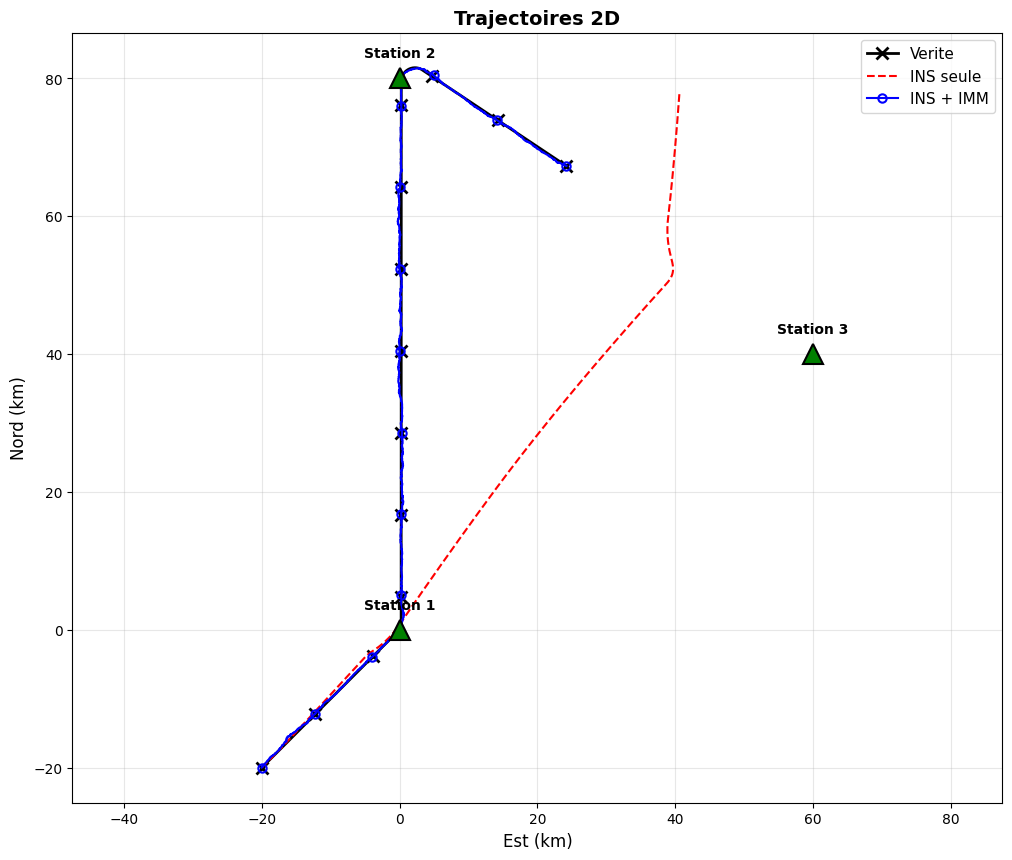

In [10]:
# Trajectoires 2D
fig1, ax1 = plot_trajectoires_2D(verite, traj_ins_seule, traj_imm, stations)
plt.show()

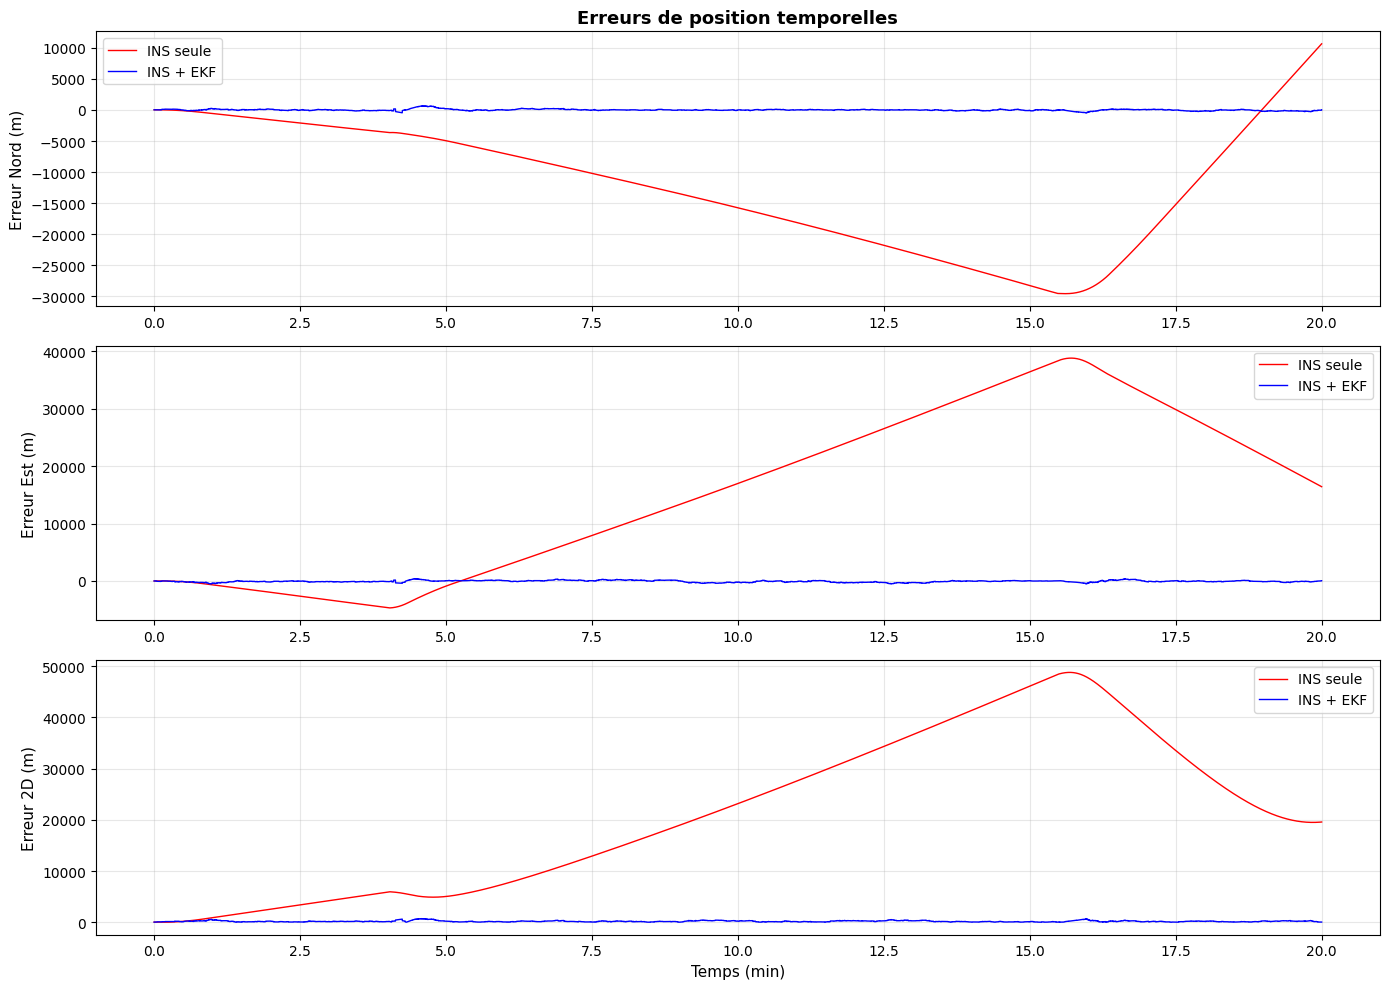

In [11]:
# Erreurs temporelles
fig2 = plot_erreurs_temporelles(verite['t'], erreurs_ins, erreurs_imm, nom_filtre='IMM')
plt.show()

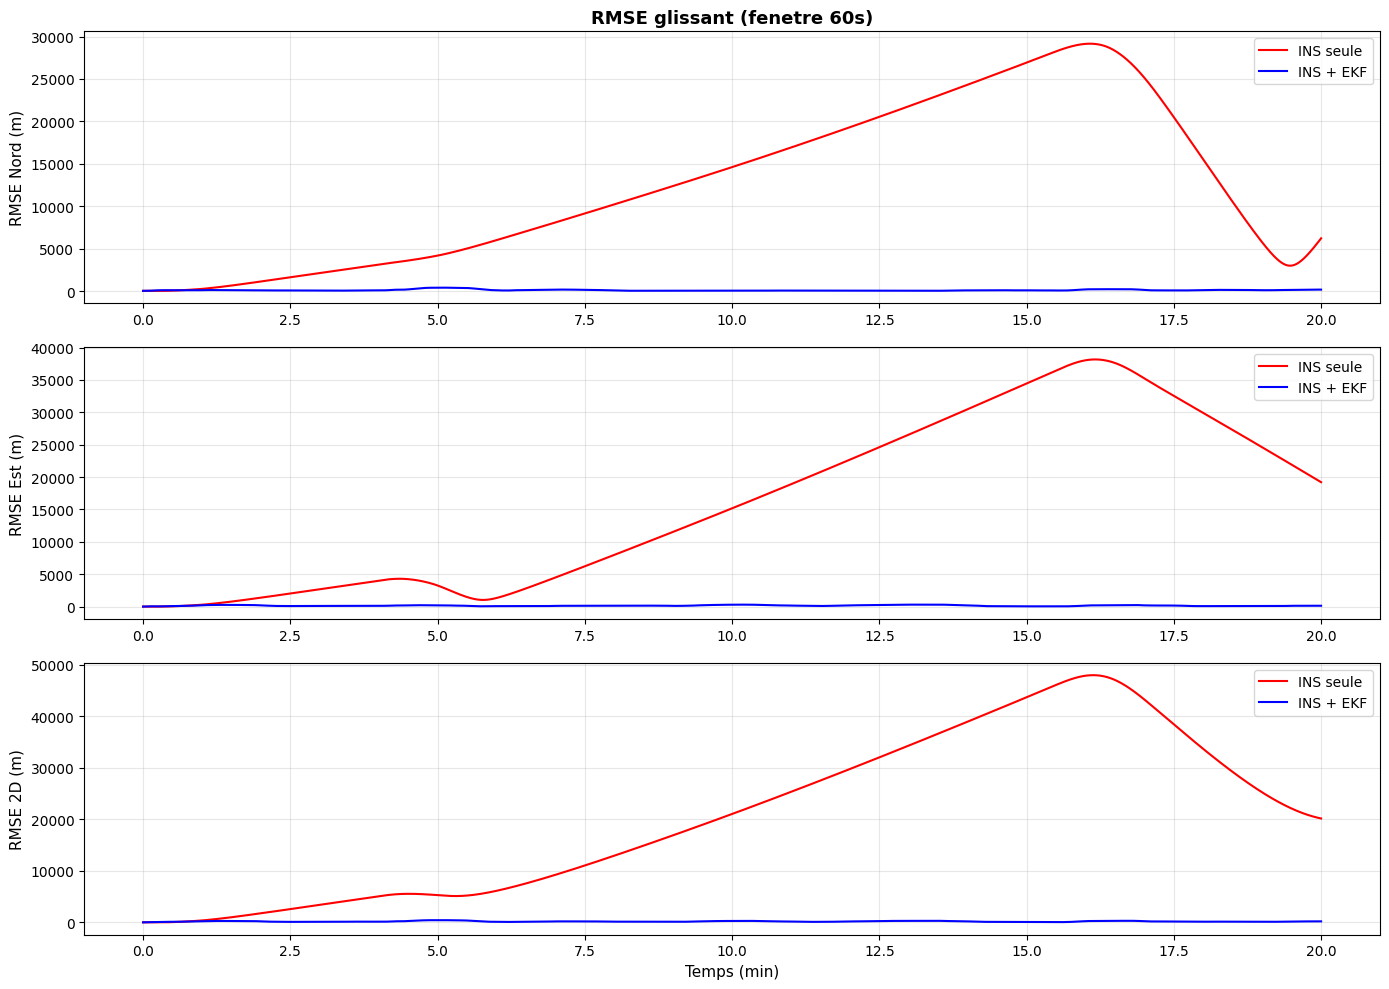

In [12]:
# RMSE glissant
fig3 = plot_rmse_glissant(verite['t'], rmse_ins, rmse_imm, params_ekf.fenetre_rmse)
plt.show()

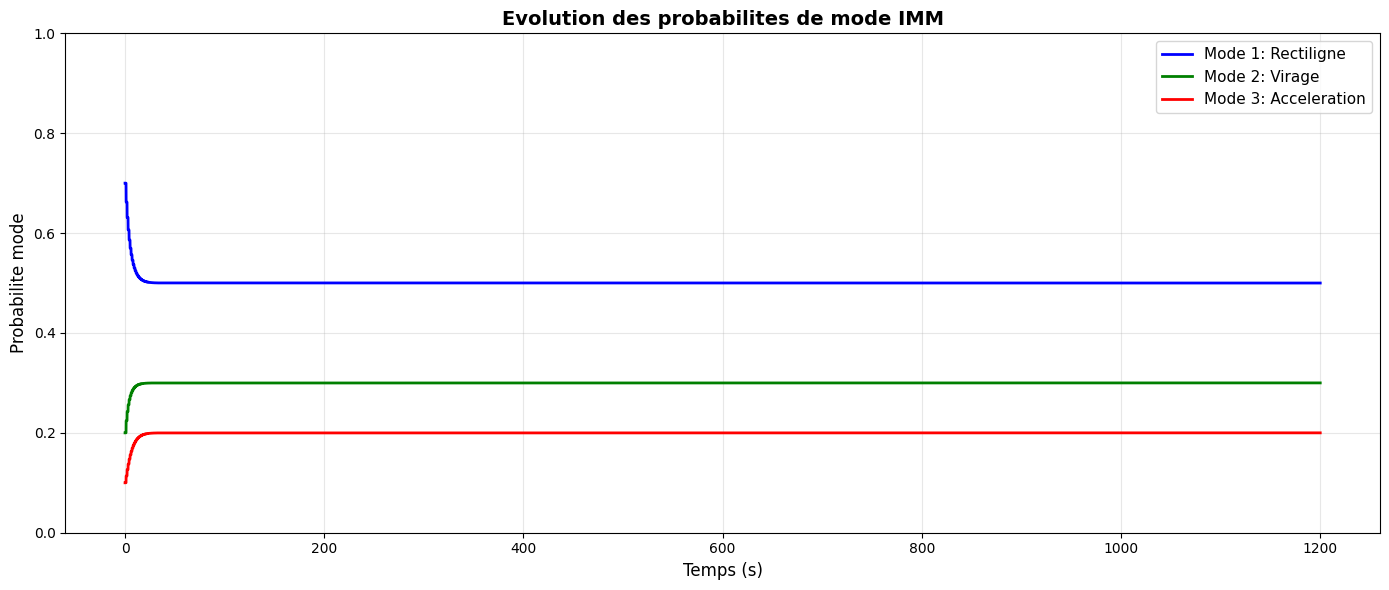

In [13]:
# Evolution probabilites modes
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(traj_imm['t'], traj_imm['mu'][:, 0], 'b-', linewidth=2, label='Mode 1: Rectiligne')
ax.plot(traj_imm['t'], traj_imm['mu'][:, 1], 'g-', linewidth=2, label='Mode 2: Virage')
ax.plot(traj_imm['t'], traj_imm['mu'][:, 2], 'r-', linewidth=2, label='Mode 3: Acceleration')

ax.set_xlabel('Temps (s)', fontsize=12)
ax.set_ylabel('Probabilite mode', fontsize=12)
ax.set_title('Evolution des probabilites de mode IMM', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [14]:
# Mode actif au cours du temps
fig, ax = plt.subplots(figsize=(14, 4))

mode_names = ['Rectiligne', 'Virage', 'Acceleration']
colors = ['blue', 'green', 'red']

for k in range(len(traj_imm['t'])):
    mode = traj_imm['mode'][k]
    ax.scatter(traj_imm['t'][k], mode, c=colors[mode], s=1, alpha=0.5)

ax.set_xlabel('Temps (s)', fontsize=12)
ax.set_ylabel('Mode actif', fontsize=12)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(mode_names)
ax.set_title('Mode actif detecte par IMM', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x000001D978545800> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000001D900F3E520> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

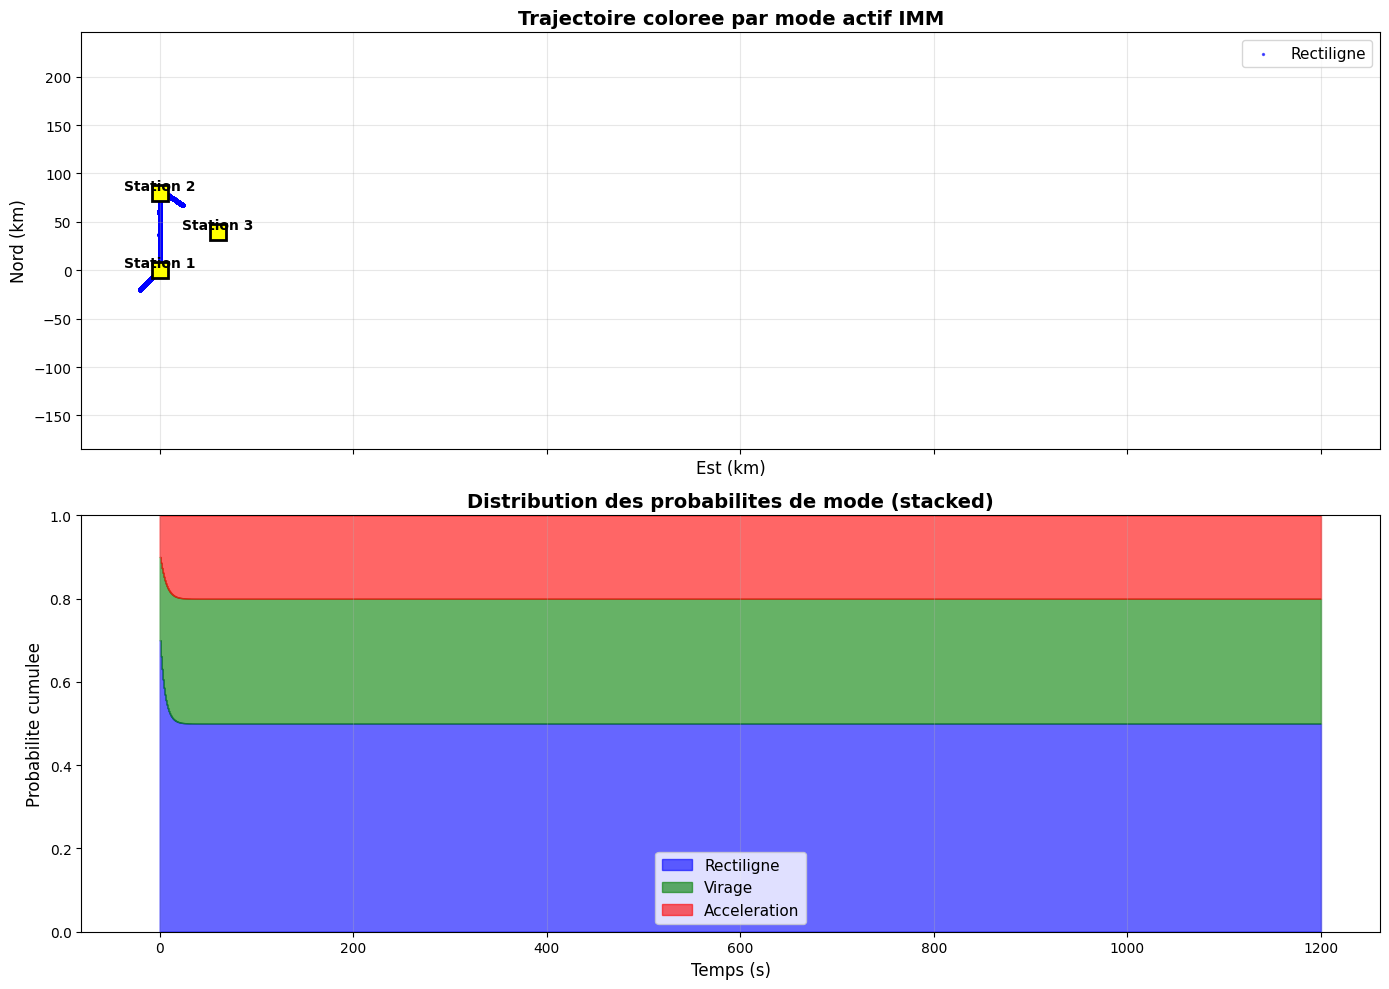

In [16]:
# Visualisation combinee: trajectoire + modes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Subplot 1: Trajectoire 2D avec couleur selon mode actif
colors_mode = ['blue', 'green', 'red']
mode_names = ['Rectiligne', 'Virage', 'Acceleration']

# Tracer la trajectoire par segments selon le mode
for mode_idx in range(3):
    mask = traj_imm['mode'] == mode_idx
    if np.any(mask):
        ax1.scatter(traj_imm['E'][mask] / 1000.0, traj_imm['N'][mask] / 1000.0, 
                   c=colors_mode[mode_idx], s=2, alpha=0.6, label=f'{mode_names[mode_idx]}')

# Stations
for station in stations:
    ax1.plot(station.position[1] / 1000.0, station.position[0] / 1000.0, 
            'ks', markersize=12, markerfacecolor='yellow', markeredgewidth=2)
    ax1.text(station.position[1] / 1000.0, station.position[0] / 1000.0 + 3, 
            station.nom, ha='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Est (km)', fontsize=12)
ax1.set_ylabel('Nord (km)', fontsize=12)
ax1.set_title('Trajectoire coloree par mode actif IMM', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# Subplot 2: Probabilites empilees (stacked area)
ax2.fill_between(traj_imm['t'], 0, traj_imm['mu'][:, 0], 
                 color='blue', alpha=0.6, label='Rectiligne')
ax2.fill_between(traj_imm['t'], traj_imm['mu'][:, 0], 
                 traj_imm['mu'][:, 0] + traj_imm['mu'][:, 1], 
                 color='green', alpha=0.6, label='Virage')
ax2.fill_between(traj_imm['t'], traj_imm['mu'][:, 0] + traj_imm['mu'][:, 1], 1.0, 
                 color='red', alpha=0.6, label='Acceleration')

ax2.set_xlabel('Temps (s)', fontsize=12)
ax2.set_ylabel('Probabilite cumulee', fontsize=12)
ax2.set_title('Distribution des probabilites de mode (stacked)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [17]:
# Analyse des transitions de mode
transitions = []
for k in range(1, len(traj_imm['mode'])):
    if traj_imm['mode'][k] != traj_imm['mode'][k-1]:
        transitions.append({
            'temps': traj_imm['t'][k],
            'de': mode_names[traj_imm['mode'][k-1]],
            'vers': mode_names[traj_imm['mode'][k]],
            'position': (traj_imm['N'][k], traj_imm['E'][k])
        })

print(f"\n{'='*70}")
print(f"ANALYSE DES TRANSITIONS DE MODE")
print(f"{'='*70}")
print(f"Nombre total de transitions: {len(transitions)}")
print(f"\nPremières transitions:")
for i, trans in enumerate(transitions[:10]):
    print(f"  t={trans['temps']:6.1f}s : {trans['de']:15s} -> {trans['vers']:15s}")
    
# Matrice de transition observee
matrice_obs = np.zeros((3, 3))
for k in range(1, len(traj_imm['mode'])):
    mode_prev = traj_imm['mode'][k-1]
    mode_curr = traj_imm['mode'][k]
    matrice_obs[mode_prev, mode_curr] += 1

# Normalisation
for i in range(3):
    total = matrice_obs[i, :].sum()
    if total > 0:
        matrice_obs[i, :] /= total

print(f"\n{'='*70}")
print("MATRICE DE TRANSITION OBSERVEE:")
print(f"{'='*70}")
print("           Rect.    Virage   Accel.")
for i, nom in enumerate(mode_names):
    print(f"{nom:12s} {matrice_obs[i, 0]:.3f}    {matrice_obs[i, 1]:.3f}    {matrice_obs[i, 2]:.3f}")

print(f"\nMATRICE DE TRANSITION THEORIQUE (Pi):")
print(f"{'='*70}")
print("           Rect.    Virage   Accel.")
for i, nom in enumerate(mode_names):
    print(f"{nom:12s} {imm_filter.Pi[i, 0]:.3f}    {imm_filter.Pi[i, 1]:.3f}    {imm_filter.Pi[i, 2]:.3f}")


ANALYSE DES TRANSITIONS DE MODE
Nombre total de transitions: 0

Premières transitions:

MATRICE DE TRANSITION OBSERVEE:
           Rect.    Virage   Accel.
Rectiligne   1.000    0.000    0.000
Virage       0.000    0.000    0.000
Acceleration 0.000    0.000    0.000

MATRICE DE TRANSITION THEORIQUE (Pi):
           Rect.    Virage   Accel.
Rectiligne   0.950    0.040    0.010
Virage       0.050    0.900    0.050
Acceleration 0.050    0.050    0.900


In [18]:
# Statistiques par mode
print(f"\n{'='*70}")
print("STATISTIQUES PAR MODE")
print(f"{'='*70}")

for mode_idx in range(3):
    mask = traj_imm['mode'] == mode_idx
    duree = np.sum(mask) * params_sim.dt_imu
    pourcentage = 100 * np.sum(mask) / len(traj_imm['mode'])
    mu_moyen = np.mean(traj_imm['mu'][mask, mode_idx]) if np.any(mask) else 0
    
    print(f"\n{mode_names[mode_idx]}:")
    print(f"  Duree active:        {duree:.1f} s ({pourcentage:.1f}%)")
    print(f"  Probabilite moyenne: {mu_moyen:.3f}")
    
    if np.any(mask):
        # Erreurs pendant ce mode
        err_2D_mode = erreurs_imm['err_2D'][mask]
        print(f"  RMSE 2D:             {np.sqrt(np.mean(err_2D_mode**2)):.2f} m")
        print(f"  Erreur max 2D:       {np.max(err_2D_mode):.2f} m")


STATISTIQUES PAR MODE

Rectiligne:
  Duree active:        1200.0 s (100.0%)
  Probabilite moyenne: 0.501
  RMSE 2D:             218.68 m
  Erreur max 2D:       708.42 m

Virage:
  Duree active:        0.0 s (0.0%)
  Probabilite moyenne: 0.000

Acceleration:
  Duree active:        0.0 s (0.0%)
  Probabilite moyenne: 0.000


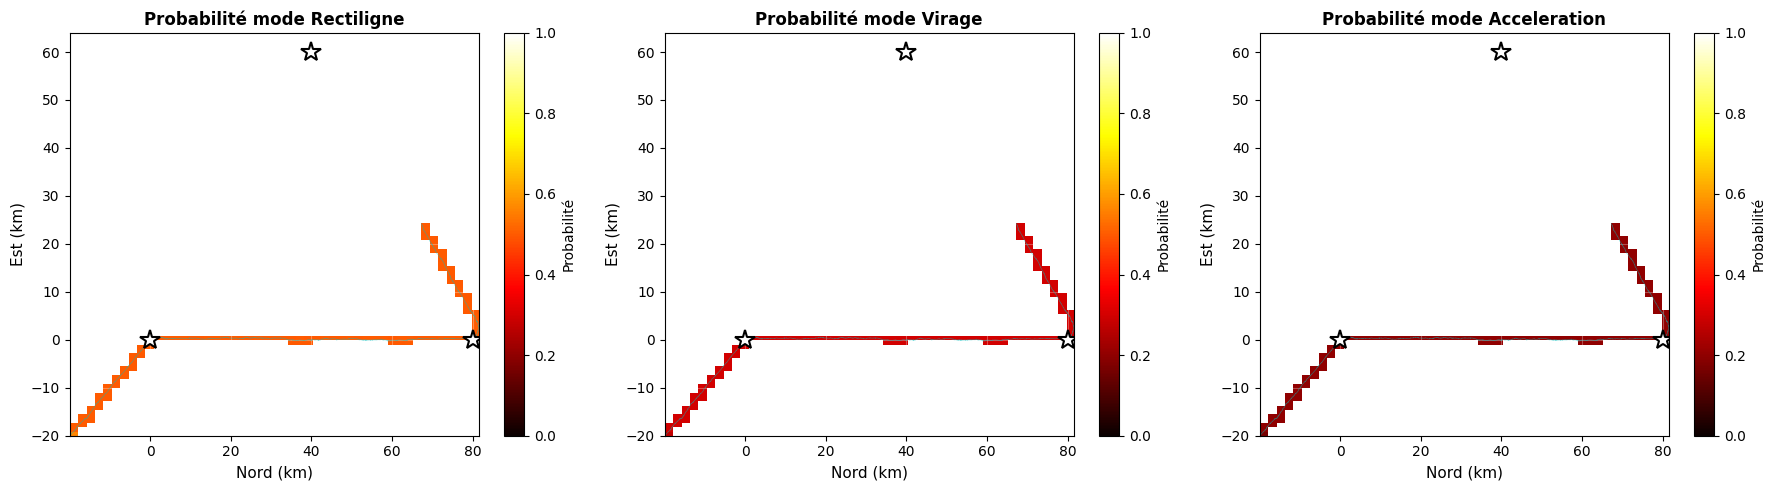

In [19]:
# Heatmap des probabilites de mode dans le plan 2D
from matplotlib.colors import LinearSegmentedColormap

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grille pour interpolation
n_bins = 50
N_bins = np.linspace(traj_imm['N'].min(), traj_imm['N'].max(), n_bins)
E_bins = np.linspace(traj_imm['E'].min(), traj_imm['E'].max(), n_bins)

for mode_idx in range(3):
    ax = axes[mode_idx]
    
    # Créer une grille de probabilités moyennes
    prob_grid = np.zeros((n_bins-1, n_bins-1))
    count_grid = np.zeros((n_bins-1, n_bins-1))
    
    for k in range(len(traj_imm['N'])):
        i = np.searchsorted(N_bins, traj_imm['N'][k]) - 1
        j = np.searchsorted(E_bins, traj_imm['E'][k]) - 1
        if 0 <= i < n_bins-1 and 0 <= j < n_bins-1:
            prob_grid[i, j] += traj_imm['mu'][k, mode_idx]
            count_grid[i, j] += 1
    
    # Moyenne
    mask = count_grid > 0
    prob_grid[mask] /= count_grid[mask]
    prob_grid[~mask] = np.nan
    
    # Affichage
    im = ax.imshow(prob_grid.T, origin='lower', aspect='auto', cmap='hot',
                   extent=[N_bins[0]/1000, N_bins[-1]/1000, E_bins[0]/1000, E_bins[-1]/1000],
                   vmin=0, vmax=1)
    
    # Trajectoire
    ax.plot(traj_imm['N'] / 1000.0, traj_imm['E'] / 1000.0, 
           'c-', linewidth=0.5, alpha=0.5)
    
    # Stations
    for station in stations:
        ax.plot(station.position[0] / 1000.0, station.position[1] / 1000.0, 
               'w*', markersize=15, markeredgecolor='black', markeredgewidth=1.5)
    
    ax.set_xlabel('Nord (km)', fontsize=11)
    ax.set_ylabel('Est (km)', fontsize=11)
    ax.set_title(f'Probabilité mode {mode_names[mode_idx]}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, color='white')
    
    plt.colorbar(im, ax=ax, label='Probabilité')

plt.tight_layout()
plt.show()

## 11. Conclusion

La simulation montre l'apport de la fusion INS + VOR/DME via IMM pour corriger la derive inertielle avec gestion multi-modeles.

Points cles:
- L'INS seule derive rapidement (biais gyro/accel)
- L'IMM corrige efficacement la position grace aux mesures VOR/DME
- Les 3 modeles (rectiligne, virage, acceleration) s'adaptent automatiquement
- Les probabilites de mode refletent la dynamique reelle de l'aeronef
- Le gating adaptatif rejette les mesures aberrantes

Avantages IMM:
- Adaptation automatique au type de manoeuvre
- Robustesse accrue en transitions
- Pas de reglage manuel de Q selon la phase de vol
- Meilleure estimation de l'incertitude

Evolutions possibles:
- Ajouter GNSS, ILS, autres aides radionav
- Passer en 3D complete avec quaternions
- Tester d'autres modeles (acceleration laterale, descente)
- Comparer quantitativement IMM vs EKF vs CMKF

In [ ]:
# Animation avec affichage forcé
import matplotlib
matplotlib.rcParams['animation.html'] = 'jshtml'

anim = animer_trajectoires(verite, traj_ins_seule, traj_ekf, stations, vitesse_lecture=50)

# Forcer affichage
from IPython.display import HTML, display
display(HTML(anim.to_jshtml()))

## Conclusion

La simulation montre l'apport de la fusion INS + VOR/DME via EKF pour corriger la derive inertielle.

Points cles:
- L'INS seule derive rapidement (biais gyro/accel)
- L'EKF corrige efficacement la position grace aux mesures VOR/DME
- Le gating rejette les mesures aberrantes
- La covariance EKF converge apres les premieres corrections

Evolutions possibles:
- Ajouter GNSS, ILS, autres aides radionav
- Passer en 3D complete avec quaternions
- Tester UKF, CKF, IMM, factor graph